<a href="https://colab.research.google.com/github/stefanogiagu/corso_AI_2026/blob/main/ising_data_sklearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
#create ising folder

Mounted at /content/drive


In [2]:
import os
ising_folder = '/content/drive/MyDrive/ising_data'

In [3]:
os.chdir(ising_folder)
!pwd

/content/drive/MyDrive/ising_data


In [4]:
#caricare i file pickle
os.chdir(ising_folder)
with open("ising_results_20x20.pkl", "rb") as f:
    data  = pickle.load(f)
    results = data["results"]

In [5]:
results[0]

{'initial_state': array([[ 1,  1, -1, -1,  1, -1, -1,  1, -1,  1, -1,  1, -1, -1,  1, -1,
         -1, -1,  1,  1],
        [ 1,  1, -1,  1,  1, -1, -1, -1,  1,  1, -1, -1,  1, -1, -1, -1,
         -1,  1,  1,  1],
        [ 1,  1, -1,  1,  1, -1, -1, -1, -1, -1, -1,  1,  1, -1, -1,  1,
          1, -1, -1,  1],
        [ 1,  1, -1,  1,  1,  1,  1, -1,  1, -1, -1,  1,  1, -1, -1,  1,
          1,  1,  1,  1],
        [-1,  1,  1,  1,  1,  1, -1,  1,  1, -1,  1, -1,  1,  1, -1,  1,
         -1,  1, -1,  1],
        [-1,  1,  1,  1, -1, -1,  1, -1,  1, -1,  1,  1,  1, -1,  1,  1,
          1,  1,  1, -1],
        [-1, -1,  1, -1, -1, -1,  1,  1,  1, -1, -1, -1, -1, -1,  1,  1,
         -1, -1, -1,  1],
        [-1, -1, -1, -1,  1,  1,  1,  1,  1, -1, -1, -1, -1, -1,  1,  1,
          1, -1,  1,  1],
        [ 1,  1,  1,  1, -1, -1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1,
         -1,  1,  1, -1],
        [-1,  1, -1,  1, -1, -1, -1, -1,  1,  1,  1,  1, -1,  1, -1,  1,
          1, -1, -1

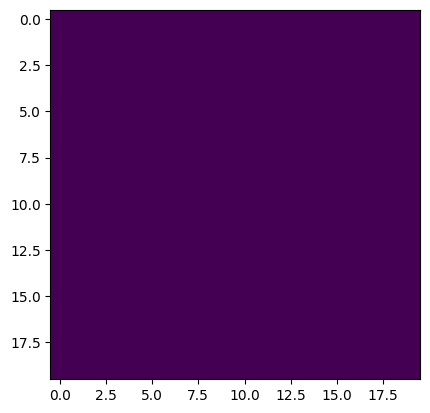

In [6]:
plt.imshow(results[0]["final_state"])

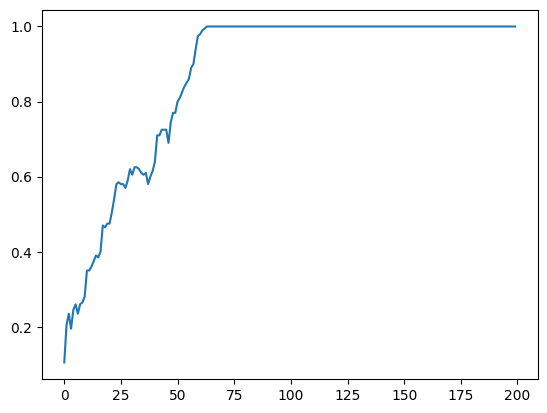

In [7]:
plt.plot(results[0]["magnetization"])

In [8]:
temperature_data = {}# fare medie di esempi alla stessa temperatura
time_array=[]#vogliamo fare un istogramma dei tempi di simulazione

for entry in results:
  temp = float(entry["temperature"])
  energy = entry["energy"]
  final_mag = entry["magnetization"][-1] # ultimo valore di array con m(t)
  t = entry["time"]
  time_array.append(t)
  state = entry["final_state"]

  if temp not in temperature_data:
    temperature_data[temp] = {"energy": [], "magnetization": [], "absolute_mag" : [],"state":[]}#se la temperatura è nuova allora creo il dizionario

  temperature_data[temp]["energy"].append(energy)
  temperature_data[temp]["magnetization"].append(final_mag)
  temperature_data[temp]["absolute_mag"].append(abs(final_mag))
  temperature_data[temp]["state"].append(state)



In [9]:
np.log(10)

np.float64(2.302585092994046)

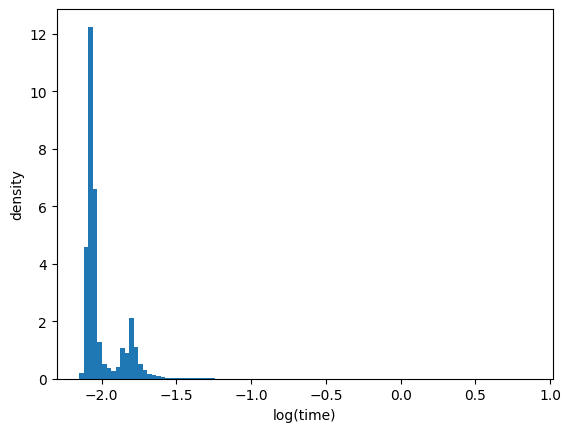

In [10]:
plt.hist(np.log10(time_array),100,density=True)
plt.xlabel("log(time)")
plt.ylabel("density")
plt.show()

In [11]:
#calcolo delle medie su insiemi alla stessa temperatura
temps =[]
avg_energies = []
avg_magnetizations=[]
all_energies=[]
all_magnetizations=[]
avg_abs_magnetizations=[]
all_temperature=[]
all_states=[]

for temp, value in sorted(temperature_data.items()):
  temps.append(temp)
  avg_energies.append(np.mean(value["energy"]))
  avg_magnetizations.append(np.mean(value["magnetization"]))
  avg_abs_magnetizations.append(np.mean(value["absolute_mag"]))

  all_energies.extend(value["energy"])# fa listone di tutte le liste a tutte le temperature
  all_magnetizations.extend(value["magnetization"])
  all_temperature.extend([temp]*len(value["energy"]))
  all_states.extend(value["state"])


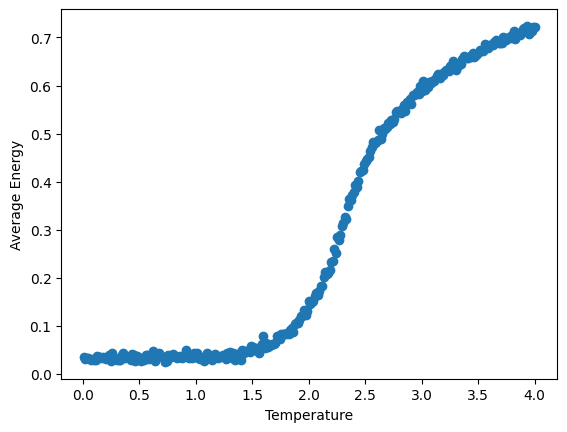

In [12]:
# scatter plot: average energy vs temperature
plt.scatter(temps, avg_energies)
plt.xlabel("Temperature")
plt.ylabel("Average Energy")
plt.show()

In [13]:
all_states[0]

array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1,

In [14]:
#all_states
#all_temperature# sono le label - le trasformiamo in itervalli [ordinato] T < 2
# 2 <T<2.5 lo chiamiamo critico
# T > 2.5 lo chiamo paramagnetico
all_temp = np.array(all_temperature)
ord_sele = all_temp < 2.0
cri_sele = ((all_temp >= 2.0) & (all_temp < 2.5))
para_sele = all_temp >= 2.5



label shape :  (30000,)
N ordered :  15000
N critical :  3700
N paramagnet :  11300


In [42]:
ord_sele

array([ True,  True,  True, ..., False, False, False])

In [43]:
#abbiamo diviso in classi il nostro dataset, assegnamo una label numerica
labels = np.zeros(shape=all_temp.shape)
labels[ord_sele] = 0
labels[cri_sele] = 1
labels[para_sele] = 2

print("label shape : ",labels.shape)
print("N ordered : ",labels[ord_sele].shape[0])
print("N critical : ",np.sum(cri_sele))
print("N paramagnet : ",np.sum(para_sele))

label shape :  (30000,)
N ordered :  15000
N critical :  3700
N paramagnet :  11300


In [46]:
labels

array([0., 0., 0., ..., 2., 2., 2.])

In [44]:
type(all_states)
states = np.array(all_states).reshape(-1,20*20)

In [45]:
states.shape

(30000, 400)

In [17]:
from sklearn.model_selection import train_test_split
train_to_rest_ratio= 0.6
vali_to_test_ratio = 0.5

X_train, X_rest, y_train, y_rest = train_test_split(states, labels, train_size=train_to_rest_ratio, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_rest, y_rest, train_size=vali_to_test_ratio, random_state=42)

In [18]:
print("X_train shape : ",X_train.shape)
print("X_val shape : ",X_val.shape)
print("X_test shape : ",X_test.shape)
#

X_train shape :  (18000, 400)
X_val shape :  (6000, 400)
X_test shape :  (6000, 400)


In [47]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import time
import math

val_accuracy_dic={}
train_accuracy_dic={}
depth_array=[]
for crit in ["gini", "entropy", "log_loss"]:
  val_accuracy_dic[crit]=[]
  train_accuracy_dic[crit]=[]

  DT_clf = DecisionTreeClassifier(max_depth=3,criterion=crit)
  DT_clf.fit(X_train,y_train)

  val_acc = DT_clf.score(X_val,y_val)
  train_acc = DT_clf.score(X_train,y_train)
  print("Training accuracy : ",train_acc)
  print("Validation accuracy : ",val_acc)
  val_accuracy_dic[crit].append(val_acc)
  train_accuracy_dic[crit].append(train_acc)




Training accuracy :  0.6471111111111111
Validation accuracy :  0.6445
Training accuracy :  0.7186111111111111
Validation accuracy :  0.719
Training accuracy :  0.7551666666666667
Validation accuracy :  0.7516666666666667
Training accuracy :  0.7721111111111111
Validation accuracy :  0.7695
Training accuracy :  0.7931666666666667
Validation accuracy :  0.7915
Training accuracy :  0.8180555555555555
Validation accuracy :  0.803
Training accuracy :  0.8343888888888888
Validation accuracy :  0.8123333333333334
Training accuracy :  0.8591666666666666
Validation accuracy :  0.799
Training accuracy :  0.8868888888888888
Validation accuracy :  0.7956666666666666
Training accuracy :  0.9107222222222222
Validation accuracy :  0.7915
Training accuracy :  0.9257222222222222
Validation accuracy :  0.798
Training accuracy :  0.9360555555555555
Validation accuracy :  0.7958333333333333
Training accuracy :  0.9438333333333333
Validation accuracy :  0.8021666666666667
Training accuracy :  0.64711111111

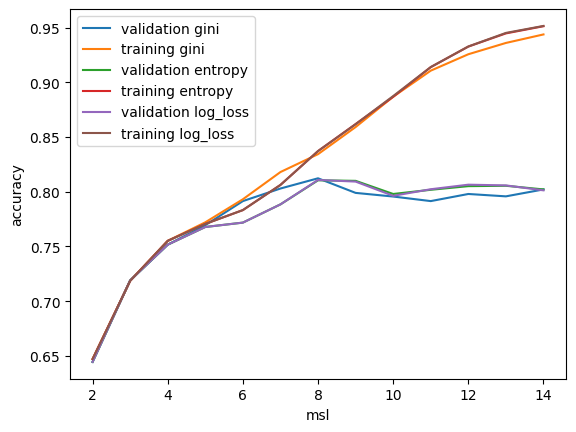

In [48]:
# plt acc vs depth
for crit in ["gini", "entropy", "log_loss"]:
  plt.plot(np.arange(2,15,1),val_accuracy_dic[crit],label=f"validation {crit}")
  plt.plot(np.arange(2,15,1),train_accuracy_dic[crit],label=f"training {crit}")
plt.xlabel("msl")
plt.ylabel("accuracy")
plt.legend()
plt.show()

In [21]:
2**20

1048576

In [49]:
states = np.array(all_states)

In [50]:
states = states.reshape(-1,20*20)

In [51]:
#pca
import sklearn
from sklearn.decomposition import PCA
pca = PCA(n_components=2)# 400 --> 2D
pc = pca.fit_transform(states)

In [53]:
pc.shape# per ogni stato finale estraggo due compomenti

(30000, 2)

In [62]:
pca.components_[0]# pc1 =  a* sum_i x_i va come la media pc1 di fatto è la magnetizzazione

array([0.05003886, 0.05001755, 0.04996507, 0.04981403, 0.05009084,
       0.05022858, 0.05020696, 0.05019407, 0.04983829, 0.05015984,
       0.0501431 , 0.05000951, 0.04999628, 0.05005476, 0.05009061,
       0.05005391, 0.05003075, 0.04994748, 0.04995509, 0.05009174,
       0.04993119, 0.0496955 , 0.04991392, 0.0499635 , 0.05011432,
       0.05004151, 0.05030139, 0.05014899, 0.04997551, 0.04993098,
       0.04997949, 0.04987895, 0.05022903, 0.04987042, 0.05004019,
       0.04978452, 0.04987945, 0.04996978, 0.04984364, 0.04992225,
       0.049832  , 0.04999515, 0.04982085, 0.04997168, 0.04992295,
       0.05019312, 0.05018608, 0.05025584, 0.05015713, 0.04993023,
       0.04986185, 0.04988315, 0.0499427 , 0.05009033, 0.05005049,
       0.05003986, 0.04986467, 0.0496452 , 0.04944898, 0.04986529,
       0.04988133, 0.04997801, 0.05012751, 0.04990182, 0.04998055,
       0.0499229 , 0.05005151, 0.0499319 , 0.05013285, 0.05002131,
       0.04985405, 0.04996976, 0.04997857, 0.04986179, 0.04995

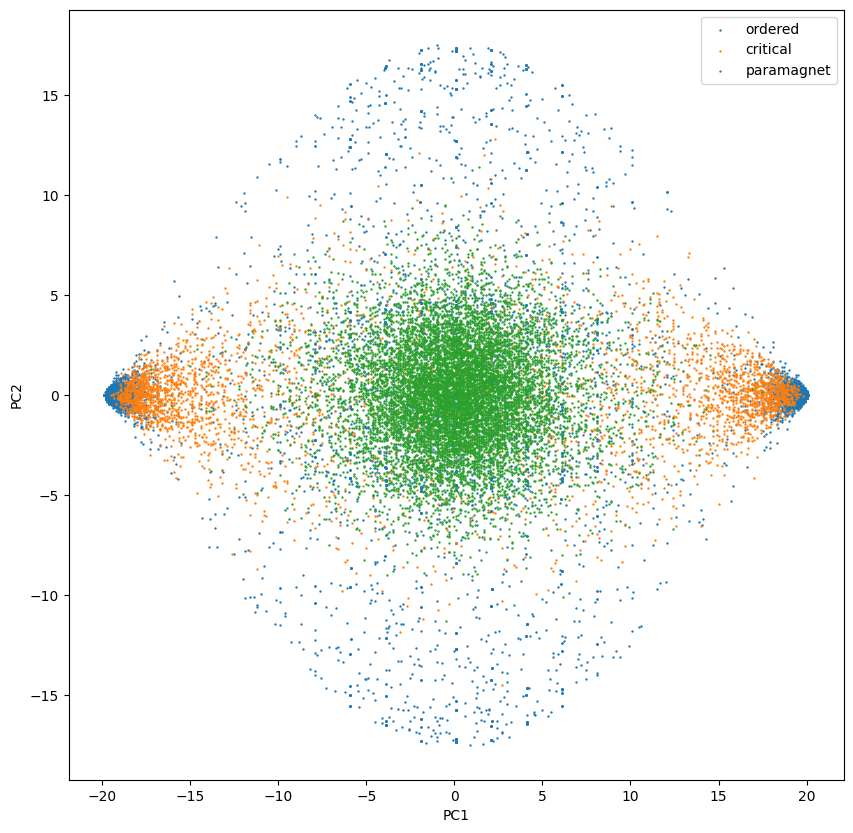

In [40]:
#plot pcs
plt.figure(figsize=(10,10))
labels_str = ["ordered","critical","paramagnet"]
for i in np.unique(labels).astype(int):
  plt.scatter(pc[labels==i,0],pc[labels==i,1],label=labels_str[i],s=0.5)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()
#

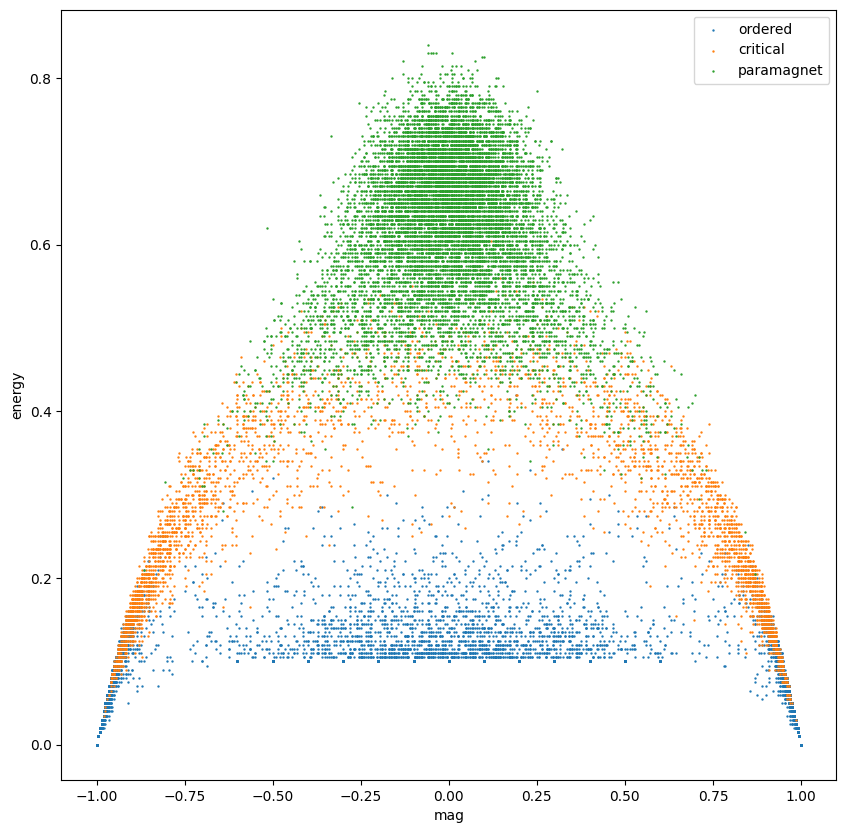

In [64]:
#scatter all energiers all magnetization
all_energies = np.array(all_energies)
all_magnetizations = np.array(all_magnetizations)
plt.figure(figsize=(10,10))
for i in np.unique(labels).astype(int):
  plt.scatter(all_magnetizations[labels==i],all_energies[labels==i],label=labels_str[i],s=0.5)
plt.xlabel("mag")
plt.ylabel("energy")
plt.legend()
plt.show()
#